# 3주차 실습 (2) - Dimensionality Reduction from scratch

> 큰 그림: **데이터는 보이는 것보다 실제로 더 단순하다.**
> 손글씨 '7' 이미지 = 784개 숫자지만, 진짜 필요한 건 몇 개(획 각도·기울기…).
> **차원 축소 = 그 "진짜 몇 개"를 찾아 784 → 2·10·50 차원으로 줄이되 구조는 지키는 것.**

## 1️⃣ 왜 줄이나 — "차원의 저주"

차원이 많아지면 이상한 일이 벌어진다:

- **거리가 무의미해짐**: 차원이 커질수록 아무 두 점이나 거리가 다 비슷해진다 → "가장 가까운 이웃 찾기"가 망가짐 (추천·검색이 다 여기 기반인데!).
- **데이터가 텅 빔**: 고차원 공간을 채우려면 데이터가 지수적으로 필요. 2D→20D만 가도 약 `10^18`배.

아래 코드로 "고차원에선 최대거리/최소거리 비율이 1에 수렴"(= 다 비슷해짐)을 직접 확인한다.

In [1]:
import numpy as np

rng = np.random.default_rng(0)
print("차원 | (최대거리/최소거리) 비율  ← 1에 가까울수록 '거리가 무의미'")
for d in [2, 10, 100, 1000]:
    pts = rng.random((100, d))
    dists = np.linalg.norm(pts[:, None, :] - pts[None, :, :], axis=-1)
    dists = dists[dists > 0]
    print(f"{d:>4} | {dists.max() / dists.min():.2f}")

차원 | (최대거리/최소거리) 비율  ← 1에 가까울수록 '거리가 무의미'
   2 | 123.94
  10 | 4.60
 100 | 1.55
1000 | 1.15


## 2️⃣ PCA — "가장 넓게 퍼진 방향부터 찾기"

**럭비공**(타원형 데이터 구름)을 상상하자:
- 공이 **길쭉한 방향** = 정보 많은 축(점들이 서로 구별됨) → **살린다**
- 공이 **납작한 방향** = 정보 적은 축(다들 비슷) → **버린다**

PCA는 좌표축을 **데이터가 퍼진 방향에 맞춰 회전**시킨 뒤, 안 퍼진 축을 버린다.

```
1. 중심화   — 평균 빼서 원점으로
2. 공분산   — 특징들이 같이 움직이는 정도
3. 고유분해 — "퍼진 방향들"을 뽑아냄   ← 핵심
4. 정렬     — 많이 퍼진 방향 순
5. 투영     — 상위 k개만 남기고 버림
```

> 💡 3번의 **고유벡터 = 퍼진 방향**, **고유값 = 그 방향으로 얼마나 퍼졌나**. 1주차 선형대수가 여기서 결실.

In [2]:
class PCA:
    def __init__(self, n_components):
        self.n_components = n_components

    def fit(self, X):
        self.mean = X.mean(0)                       # 1. 중심화
        Xc = X - self.mean
        cov = np.cov(Xc, rowvar=False)              # 2. 공분산
        vals, vecs = np.linalg.eigh(cov)            # 3. 고유분해 (대칭 -> eigh)
        order = np.argsort(vals)[::-1]              # 4. 분산 큰 순
        vals, vecs = vals[order], vecs[:, order]
        self.components = vecs[:, :self.n_components].T   # 5. 상위 k
        self.explained_variance_ratio_ = vals[:self.n_components] / vals.sum()
        return self

    def transform(self, X):
        return (X - self.mean) @ self.components.T

    def fit_transform(self, X):
        return self.fit(X).transform(X)


print("PCA 클래스 준비 완료")

PCA 클래스 준비 완료


### 🖼️ 그림 1 — 회전과 투영 (PCA가 실제로 하는 일)

왼쪽: 원본 데이터 구름 + **주성분 축**(PC1=길쭉, PC2=납작).
오른쪽: PC2를 버리고 **PC1에만 투영**(2D→1D). 길쭉한 방향의 퍼짐은 거의 그대로 남는다.

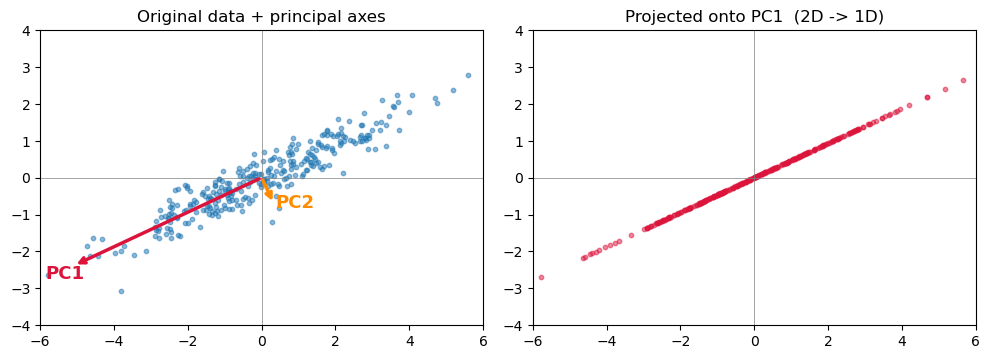

In [3]:
import matplotlib.pyplot as plt

# 길쭉한(상관 있는) 2D 데이터
rng = np.random.default_rng(0)
n = 300
a = rng.normal(0, 1, n)
X = np.column_stack([2.0 * a, 0.9 * a + rng.normal(0, 0.35, n)])
X = X - X.mean(0)

cov = np.cov(X, rowvar=False)
vals, vecs = np.linalg.eigh(cov)
order = np.argsort(vals)[::-1]
vals, vecs = vals[order], vecs[:, order]

fig, ax = plt.subplots(1, 2, figsize=(10, 4.2))
colors = ["crimson", "darkorange"]
ax[0].scatter(X[:, 0], X[:, 1], s=10, alpha=0.5)
for i, (val, vec) in enumerate(zip(vals, vecs.T)):
    v = vec * np.sqrt(val) * 2.5
    ax[0].annotate("", xy=v, xytext=(0, 0),
                   arrowprops=dict(arrowstyle="->", lw=2.5, color=colors[i]))
    ax[0].text(v[0] * 1.15, v[1] * 1.15, f"PC{i+1}", color=colors[i],
               fontsize=13, fontweight="bold")
ax[0].set_title("Original data + principal axes")

pc1 = vecs[:, 0]
proj = (X @ pc1)[:, None] * pc1[None, :]     # PC1에 투영
ax[1].scatter(proj[:, 0], proj[:, 1], s=10, alpha=0.5, color="crimson")
ax[1].set_title("Projected onto PC1  (2D -> 1D)")

for a_ in ax:
    a_.set_aspect("equal")
    a_.axhline(0, color="gray", lw=0.5)
    a_.axvline(0, color="gray", lw=0.5)
    a_.set_xlim(-6, 6); a_.set_ylim(-4, 4)
plt.tight_layout()
plt.show()

## 3️⃣ 얼마나 남길까 — "설명분산비"

각 주성분이 전체 퍼짐 중 몇 %를 담당하는지가 **설명분산비**.

아래 3D 합성 데이터(원은 원래 원 위 + 잉여 축)를 2D로 줄이면 두 성분이 대부분을 설명한다.

In [4]:
rng = np.random.default_rng(42)
t = rng.uniform(0, 2 * np.pi, 500)
x1 = 3 * np.cos(t) + rng.normal(0, 0.2, 500)
x2 = 3 * np.sin(t) + rng.normal(0, 0.2, 500)
x3 = 0.5 * x1 + 0.3 * x2 + rng.normal(0, 0.1, 500)   # 잉여(선형결합) 차원
X3 = np.column_stack([x1, x2, x3])

pca = PCA(n_components=2).fit(X3)
print(f"설명분산비: {np.round(pca.explained_variance_ratio_, 4)}  (PC1, PC2)")
print(f"누적 분산:  {pca.explained_variance_ratio_.sum():.4f}  <- 2차원만으로 대부분 설명!")

설명분산비: [0.5932 0.4061]  (PC1, PC2)
누적 분산:  0.9993  <- 2차원만으로 대부분 설명!


### 🖼️ 그림 2 — 스크리(scree) 그래프와 "엘보"

성분별 설명분산(막대)과 누적(선). **누적이 확 꺾이는 지점(엘보)**까지만 남기면 된다.
아래 데이터는 사실상 **3차원**이라 3번째 성분 뒤에서 곡선이 평평해진다.

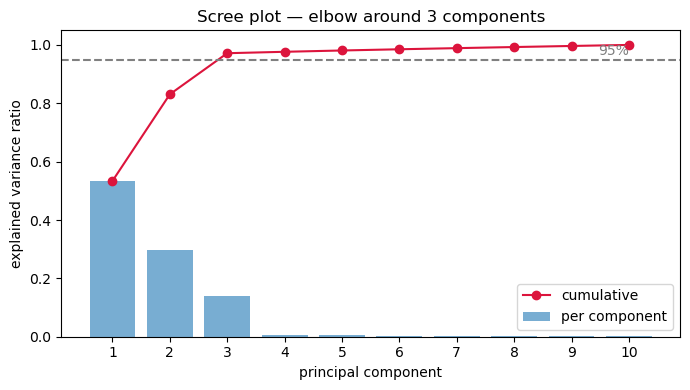

In [5]:
# 겉보기 10차원이지만 실제로는 3개 잠재요인으로 만든 데이터
rng = np.random.default_rng(1)
latent = rng.normal(0, 1, (500, 3)) * np.array([4.0, 3.0, 2.0])   # 세 방향의 퍼짐
Xh = np.zeros((500, 10))
Xh[:, :3] = latent
Xh += rng.normal(0, 0.35, (500, 10))                 # 나머지는 약한 노이즈
Q, _ = np.linalg.qr(rng.normal(0, 1, (10, 10)))      # 직교 회전(고유값 보존, 축 정렬만 깸)
Xh = (Xh - Xh.mean(0)) @ Q

vals = np.sort(np.linalg.eigvalsh(np.cov(Xh, rowvar=False)))[::-1]
ratio = vals / vals.sum()
cum = np.cumsum(ratio)

fig, ax = plt.subplots(figsize=(7, 4))
comps = np.arange(1, len(ratio) + 1)
ax.bar(comps, ratio, alpha=0.6, label="per component")
ax.plot(comps, cum, "o-", color="crimson", label="cumulative")
ax.axhline(0.95, ls="--", color="gray")
ax.text(len(comps), 0.955, "95%", ha="right", va="bottom", color="gray")
ax.set_xlabel("principal component")
ax.set_ylabel("explained variance ratio")
ax.set_title("Scree plot — elbow around 3 components")
ax.set_xticks(comps)
ax.legend()
plt.tight_layout()
plt.show()

## 4️⃣ PCA vs t-SNE / UMAP — 용도가 다르다

| | PCA | t-SNE / UMAP |
| --- | --- | --- |
| 뭐 하나 | 분산 큰 방향 살리기 (선형) | 이웃 관계 보존 (비선형) |
| 용도 | **전처리·압축** | **눈으로 보는 시각화** |
| 속도 | 빠름 (수백만 개 OK) | 느림 |

- **PCA**: 학습 전 784→50차원으로 눌러 노이즈 빼고 속도 올릴 때.
- **t-SNE/UMAP**: 고차원을 2D 그림으로 그려 "클러스터로 뭉치나" 눈으로 볼 때.

> ⚠️ **t-SNE 함정**: 클러스터가 뭉친 건 믿어도 되지만, **클러스터 사이 거리는 의미 없다.**

## 🎯 한 문장 정리

> **PCA = 데이터 럭비공을 가장 길쭉한 방향에 맞춰 돌린 뒤, 납작한 축을 버리는 것.**
> 핵심은 공분산 행렬의 **고유벡터(방향) + 고유값(퍼짐 크기)** — 1주차 선형대수가 결실 맺는 곳.

| 개념 | 한 줄 |
| --- | --- |
| 차원의 저주 | 차원 많으면 거리·밀도가 망가짐 |
| PCA | 분산 큰 방향 살리고 작은 방향 버림 (선형, 전처리) |
| 설명분산비 | 각 방향이 담은 정보 % (누적 95%까지) |
| t-SNE/UMAP | 이웃 보존해 2D로 (시각화, 클러스터 간 거리는 무의미) |

개념 노트: [[📉 차원 축소 (PCA·t-SNE·UMAP)]] (Obsidian LLM_Wiki)